# SEÇÃO 1 — CARREGAMENTO

In [ ]:
import kagglehub
path = kagglehub.dataset_download("matheusfreitag/gas-prices-in-brazil")

100%|██████████| 3.08M/3.08M [00:00<00:00, 103MB/s]

Extracting files...


In [ ]:
import os
os.listdir(path)

['2004-2021.tsv']

In [ ]:
df = pd.read_csv(f'{path}/2004-2021.tsv', sep='\t', encoding='utf-8')
df.shape

(120823, 18)

In [ ]:
# 1. Visão geral
print(df.dtypes)
print()
print(df.sample(5))

DATA INICIAL                      object
DATA FINAL                        object
REGIÃO                            object
ESTADO                            object
PRODUTO                           object
NÚMERO DE POSTOS PESQUISADOS       int64
UNIDADE DE MEDIDA                 object
PREÇO MÉDIO REVENDA              float64
DESVIO PADRÃO REVENDA            float64
PREÇO MÍNIMO REVENDA             float64
PREÇO MÁXIMO REVENDA             float64
MARGEM MÉDIA REVENDA              object
COEF DE VARIAÇÃO REVENDA         float64
PREÇO MÉDIO DISTRIBUIÇÃO          object
DESVIO PADRÃO DISTRIBUIÇÃO        object
PREÇO MÍNIMO DISTRIBUIÇÃO         object
PREÇO MÁXIMO DISTRIBUIÇÃO         object
COEF DE VARIAÇÃO DISTRIBUIÇÃO     object
dtype: object

       DATA INICIAL  DATA FINAL    REGIÃO    ESTADO           PRODUTO  \
16794    2007-09-30  2007-10-06  NORDESTE     CEARA    GASOLINA COMUM   
25435    2005-04-10  2005-04-16  NORDESTE  MARANHAO               GLP   
19803    2009-11-29  2009-12

In [ ]:
# 2. Parsear datas e extrair ano
df['DATA INICIAL'] = pd.to_datetime(df['DATA INICIAL'])
df['DATA FINAL'] = pd.to_datetime(df['DATA FINAL'])
df['ANO'] = df['DATA INICIAL'].dt.year

print(df['DATA INICIAL'].min(), 'a', df['DATA INICIAL'].max())

2004-05-09 00:00:00 a 2021-04-25 00:00:00


In [ ]:
# 3. Aqui está o problema que mencionei — olha com atenção
print(df['PRODUTO'].value_counts())

PRODUTO
GASOLINA COMUM        23570
GLP                   23561
ETANOL HIDRATADO      23440
ÓLEO DIESEL           21194
GNV                   14469
ÓLEO DIESEL S10        9113
OLEO DIESEL S10        2376
OLEO DIESEL            2351
GASOLINA ADITIVADA      749
Name: count, dtype: int64


In [ ]:
df['PRODUTO'] = df['PRODUTO'].str.replace('ÓLEO', 'OLEO')
print(df['PRODUTO'].value_counts())

PRODUTO
GASOLINA COMUM        23570
GLP                   23561
OLEO DIESEL           23545
ETANOL HIDRATADO      23440
GNV                   14469
OLEO DIESEL S10       11489
GASOLINA ADITIVADA      749
Name: count, dtype: int64


In [ ]:
# Checklist final antes da EDA
print("Shape:", df.shape)
print("Nulos:\n", df.isnull().sum())
print("Anos disponíveis:", sorted(df['ANO'].unique()))
print("Estados únicos:", df['ESTADO'].nunique(), "estados")

Shape: (120823, 19)
Nulos:
 DATA INICIAL                     0
DATA FINAL                       0
REGIÃO                           0
ESTADO                           0
PRODUTO                          0
NÚMERO DE POSTOS PESQUISADOS     0
UNIDADE DE MEDIDA                0
PREÇO MÉDIO REVENDA              0
DESVIO PADRÃO REVENDA            0
PREÇO MÍNIMO REVENDA             0
PREÇO MÁXIMO REVENDA             0
MARGEM MÉDIA REVENDA             0
COEF DE VARIAÇÃO REVENDA         0
PREÇO MÉDIO DISTRIBUIÇÃO         0
DESVIO PADRÃO DISTRIBUIÇÃO       0
PREÇO MÍNIMO DISTRIBUIÇÃO        0
PREÇO MÁXIMO DISTRIBUIÇÃO        0
COEF DE VARIAÇÃO DISTRIBUIÇÃO    0
ANO                              0
dtype: int64
Anos disponíveis: [np.int32(2004), np.int32(2005), np.int32(2006), np.int32(2007), np.int32(2008), np.int32(2009), np.int32(2010), np.int32(2011), np.int32(2012), np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.

# SEÇÃO 2 — EDA: EVOLUÇÃO TEMPORAL
1. *Qual* *foi* a evolução do preço médio de revenda da Gasolina Comum no Brasil ao longo dos anos? Existe algum padrão sazonal visível?

In [ ]:
### Importar a biblioteca pra plotar o gráfico
import matplotlib.pyplot as plt

In [ ]:
### definir o produto
gasolina = df[df['PRODUTO'] == 'GASOLINA COMUM']

In [ ]:
### groupby de gasolina pelo preco médio por ano
preco_ano = gasolina.groupby('ANO')['PREÇO MÉDIO REVENDA'].mean()

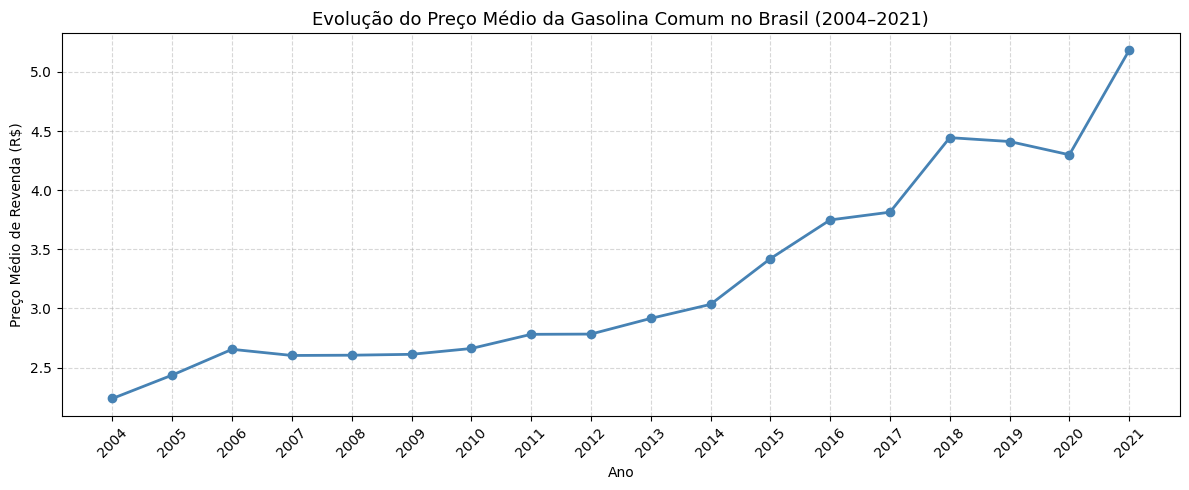

In [ ]:
# 3. Plot
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(preco_ano.index, preco_ano.values, marker='o', linewidth=2, color='steelblue')
ax.set_title('Evolução do Preço Médio da Gasolina Comum no Brasil (2004–2021)', fontsize=13)
ax.set_xlabel('Ano')
ax.set_ylabel('Preço Médio de Revenda (R$)')
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_xticks(preco_ano.index)
ax.set_xticklabels(preco_ano.index, rotation=45)
plt.tight_layout()
plt.show()

Achados — Evolução do Preço da Gasolina Comum (2004–2021)

Entre 2006 e 2013, os preços permaneceram praticamente estagnados em torno de R$ 2,60, reflexo da política de subsídio e controle artificial praticada pela Petrobras no período.
A partir de 2016, com a adoção da PPI (Paridade de Preço Internacional), os preços passaram a seguir as cotações do mercado global, provocando alta de ~46% entre 2014 e 2018.
Em 2020, a queda da demanda global por petróleo durante a pandemia de Covid-19 gerou leve recuo. Em 2021, a recuperação da demanda combinada com desvalorização cambial empurrou o preço ao maior patamar da série: ~R$ 5,20.

2. Qual região do Brasil consistentemente paga mais caro pela Gasolina Comum e pelo Etanol Hidratado? A diferença regional se manteve estável ao longo do tempo ou mudou?

Gasolina Comum

In [ ]:
preco_regional = gasolina.groupby(['ANO', 'REGIÃO'])['PREÇO MÉDIO REVENDA'].mean().unstack()
print(preco_regional.head())

REGIÃO  CENTRO OESTE  NORDESTE     NORTE   SUDESTE       SUL
ANO                                                         
2004        2.288507  2.186523  2.351059  2.126941  2.217078
2005        2.497875  2.392278  2.541977  2.297705  2.431240
2006        2.720005  2.644031  2.726310  2.529325  2.599629
2007        2.676433  2.611556  2.641758  2.506731  2.514205
2008        2.630981  2.595004  2.701418  2.506760  2.505737


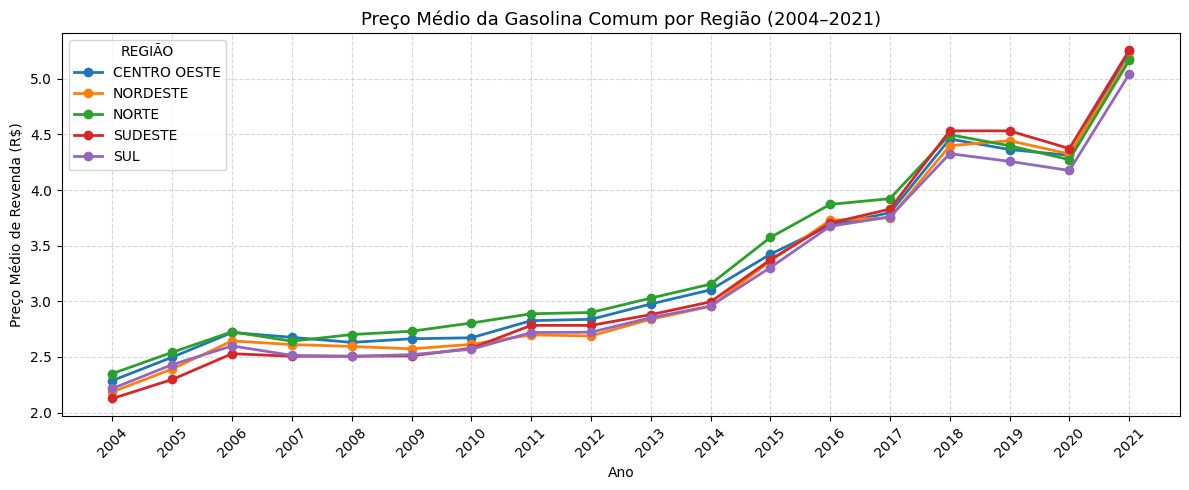

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
preco_regional.plot(ax=ax, marker='o', linewidth=2)
ax.set_title('Preço Médio da Gasolina Comum por Região (2004–2021)', fontsize=13)
ax.set_xlabel('Ano')
ax.set_ylabel('Preço Médio de Revenda (R$)')
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_xticks(preco_ano.index)
ax.set_xticklabels(preco_ano.index, rotation=45)
plt.tight_layout()
plt.show()

A região Norte pagou consistentemente os maiores preços do país ao longo de toda a série, reflexo do custo logístico elevado de distribuição numa região com infraestrutura modal limitada.
O Sudeste assumiu o topo em 2018, impulsionado pelo choque de abastecimento da greve dos caminhoneiros e pela posterior política de reajustes frequentes atrelados ao dólar.
O Nordeste apresentou os menores preços em boa parte da série, beneficiado por incentivos fiscais regionais e pela proximidade com a produção de etanol, que pressiona o preço da gasolina para baixo.

Etanol Hidratado

In [ ]:
print(df['PRODUTO'].unique())

['ETANOL HIDRATADO' 'GASOLINA COMUM' 'GLP' 'GNV' 'OLEO DIESEL'
 'OLEO DIESEL S10' 'GASOLINA ADITIVADA']


In [ ]:
etanol = df[df['PRODUTO'] == 'ETANOL HIDRATADO']

In [ ]:
preco_etanol = etanol.groupby(['ANO', 'REGIÃO'])['PREÇO MÉDIO REVENDA'].mean().unstack()
print(preco_etanol.head())

REGIÃO  CENTRO OESTE  NORDESTE     NORTE   SUDESTE       SUL
ANO                                                         
2004        1.502309  1.534441  1.736340  1.274912  1.396853
2005        1.630055  1.711411  1.900959  1.466315  1.611667
2006        1.880292  1.953212  2.171461  1.794656  1.880478
2007        1.597981  1.764425  1.949640  1.613649  1.638378
2008        1.634000  1.793338  1.988585  1.589534  1.628506


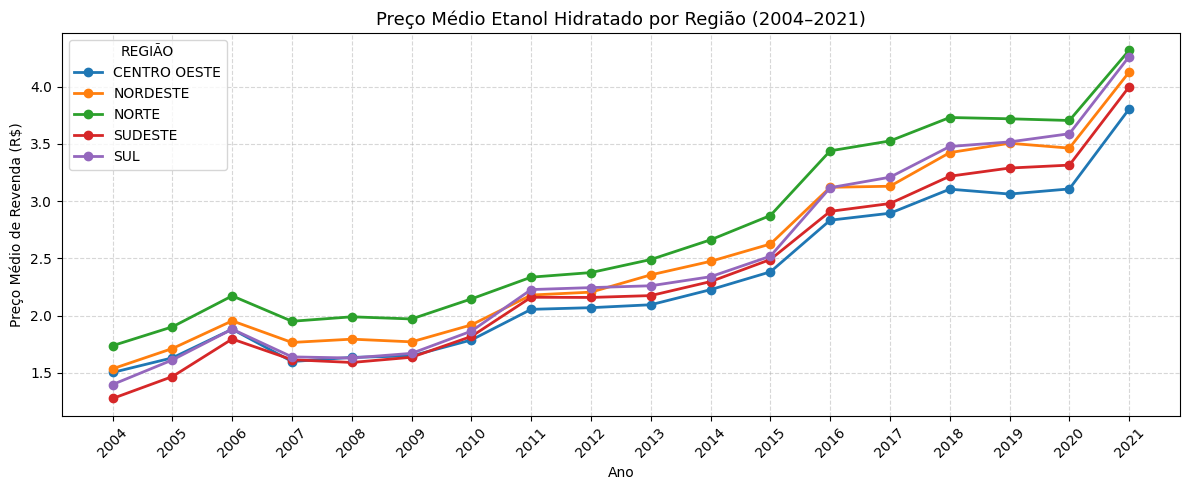

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
preco_etanol.plot(ax=ax, marker='o', linewidth=2)
ax.set_title('Preço Médio Etanol Hidratado por Região (2004–2021)', fontsize=13)
ax.set_xlabel('Ano')
ax.set_ylabel('Preço Médio de Revenda (R$)')
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_xticks(preco_ano.index)
ax.set_xticklabels(preco_ano.index, rotation=45)
plt.tight_layout()
plt.show()

No etanol, o padrão regional se repete: Norte consistentemente mais caro por todo o período, pelo mesmo problema logístico de distribuição.
O Sudeste, maior produtor de cana do país, apresentou os menores preços de etanol até 2011 — vantagem de proximidade com a produção. A partir daí o Sul passou a competir e eventualmente assumiu o menor preço, possivelmente reflexo da expansão da produção sucroalcooleira na região Sul.
Diferente da gasolina, onde as regiões andam juntas, o etanol tem uma dispersão regional muito maior — a diferença Norte vs. Sudeste chega a ser mais pronunciada, o que reforça que o etanol é um produto com precificação mais sensível à distância da produção.

3. Qual é a margem média de revenda por produto? Qual combustível tem a maior margem praticada pelos postos?

In [ ]:
df['MARGEM MÉDIA REVENDA'] = pd.to_numeric(df['MARGEM MÉDIA REVENDA'], errors='coerce')
print(df['MARGEM MÉDIA REVENDA'].dtype)
print(df['MARGEM MÉDIA REVENDA'].isnull().sum())

float64
3431


In [ ]:
margem_produto = df.groupby('PRODUTO')['MARGEM MÉDIA REVENDA'].mean().sort_values(ascending=False)
print(margem_produto)

PRODUTO
OLEO DIESEL           -3228.794883
GASOLINA COMUM        -3254.848682
GLP                   -3361.490315
ETANOL HIDRATADO      -3672.023700
GNV                   -6799.552678
OLEO DIESEL S10       -6909.248470
GASOLINA ADITIVADA   -99999.000000
Name: MARGEM MÉDIA REVENDA, dtype: float64


In [ ]:
df_margem = df[(df['MARGEM MÉDIA REVENDA'] > 0) & (df['MARGEM MÉDIA REVENDA'] < 2)]

margem_produto = df_margem.groupby('PRODUTO')['MARGEM MÉDIA REVENDA'].mean().sort_values(ascending=False)
print(margem_produto)

PRODUTO
GLP                 1.500875
GNV                 0.510490
GASOLINA COMUM      0.412461
OLEO DIESEL S10     0.378592
ETANOL HIDRATADO    0.328994
OLEO DIESEL         0.282128
Name: MARGEM MÉDIA REVENDA, dtype: float64


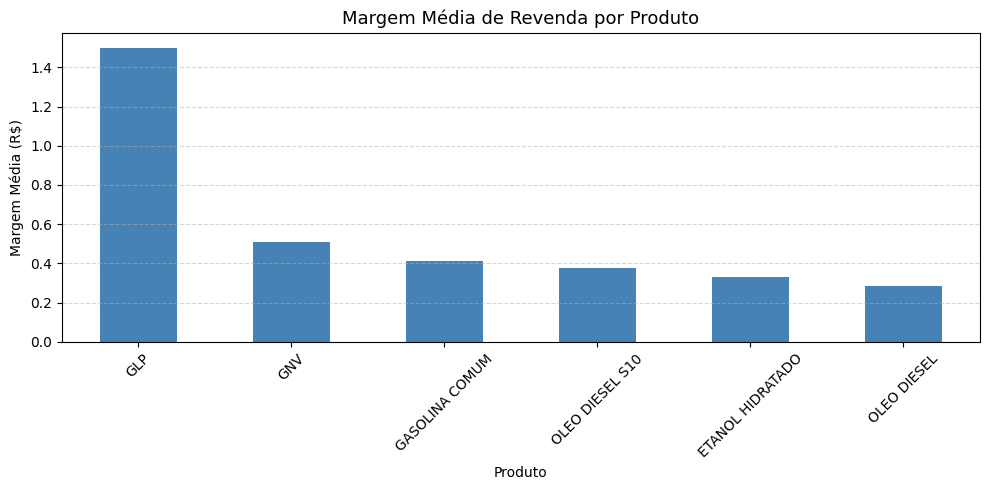

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
margem_produto.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Margem Média de Revenda por Produto', fontsize=13)
ax.set_xlabel('Produto')
ax.set_ylabel('Margem Média (R$)')
ax.tick_params(axis='x', rotation=45)
ax.grid(True, linestyle='--', alpha=0.5, axis='y')
plt.tight_layout()
plt.show()

Entre os combustíveis líquidos, a Gasolina Comum apresenta a maior margem média de revenda (~R$ 0,41/litro), enquanto o Óleo Diesel tem a menor (~R$ 0,28/litro). A diferença é pequena, sugerindo que os postos operam com margens relativamente homogêneas entre produtos.

In [ ]:
df.to_csv('combustiveis_tratado.csv', index=False)

In [ ]:
from google.colab import files
files.download('combustiveis_tratado.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving combustiveis_tratado.csv to combustiveis_tratado.csv


In [ ]:
df = pd.read_csv('combustiveis_tratado.csv')
print(df.shape)

(120823, 19)


4. Como se comporta a relação preço de distribuição × preço de revenda ao longo dos anos? A margem dos postos cresceu ou foi comprimida com o tempo?

In [ ]:
df['PREÇO MÉDIO DISTRIBUIÇÃO'] = pd.to_numeric(df['PREÇO MÉDIO DISTRIBUIÇÃO'], errors='coerce')
df['PREÇO MÉDIO REVENDA'] = pd.to_numeric(df['PREÇO MÉDIO REVENDA'], errors='coerce')

df['MARGEM_CALCULADA'] = df['PREÇO MÉDIO REVENDA'] - df['PREÇO MÉDIO DISTRIBUIÇÃO']
print(df['MARGEM_CALCULADA'].describe())

count    117423.000000
mean       4693.601225
std       21146.581961
min          -4.585000
25%           0.294000
50%           0.401000
75%           0.732000
max      100106.500000
Name: MARGEM_CALCULADA, dtype: float64


In [ ]:
df_margem2 = df[(df['MARGEM_CALCULADA'] > 0) & (df['MARGEM_CALCULADA'] < 2)]
print(df_margem2['MARGEM_CALCULADA'].describe())

count    89958.000000
mean         0.367565
std          0.143173
min          0.001000
25%          0.266000
50%          0.351000
75%          0.440000
max          1.928000
Name: MARGEM_CALCULADA, dtype: float64


In [ ]:
margem_ano = df_margem2.groupby('ANO')['MARGEM_CALCULADA'].mean()
print(margem_ano)

ANO
2004    0.304419
2005    0.282188
2006    0.304835
2007    0.314670
2008    0.315421
2009    0.316978
2010    0.321952
2011    0.309769
2012    0.318400
2013    0.338635
2014    0.354291
2015    0.403604
2016    0.422517
2017    0.461420
2018    0.453166
2019    0.468949
2020    0.484479
Name: MARGEM_CALCULADA, dtype: float64


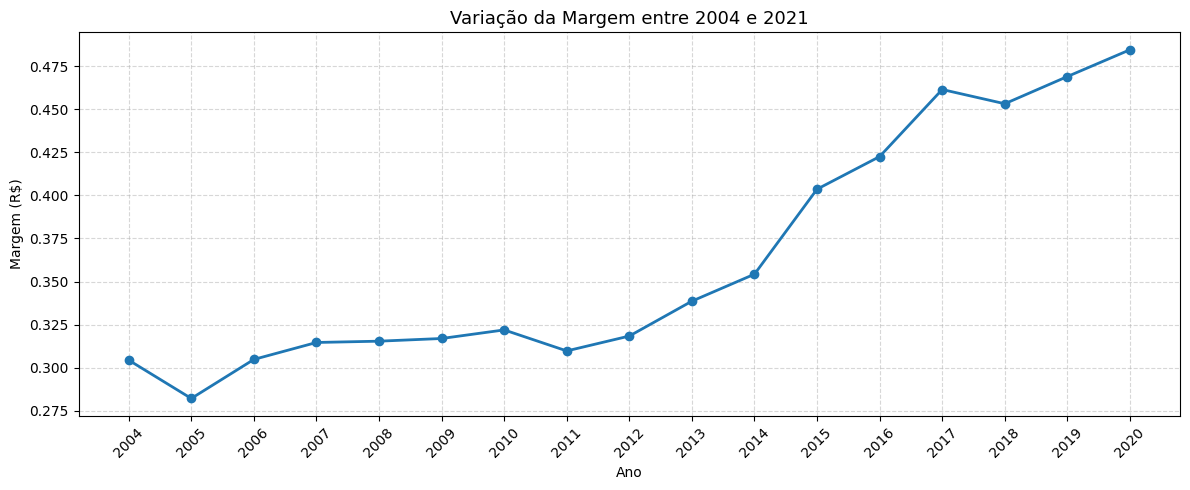

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
margem_ano.plot(ax=ax, marker='o', linewidth=2)
ax.set_title('Variação da Margem entre 2004 e 2021', fontsize=13)
ax.set_xlabel('Ano')
ax.set_ylabel('Margem (R$)')
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_xticks(margem_ano.index)
ax.set_xticklabels(margem_ano.index, rotation=45)
plt.tight_layout()
plt.show()

A margem dos postos permaneceu estável entre R$ 0,28 e R$ 0,32 até 2013, período de controle artificial de preços pela Petrobras. A partir de 2014, com a adoção da PPI e o fim do subsídio, a margem acelerou consistentemente, atingindo ~R$ 0,48 em 2020 — um crescimento de ~60% em 7 anos. A volatilidade de preços favoreceu os revendedores, que ampliaram margens para absorver o risco.

5. O coeficiente de variação (dispersão de preços entre postos) aumentou ou diminuiu ao longo dos anos para a Gasolina Comum? O mercado ficou mais ou menos homogêneo?

In [ ]:
print(df.columns.tolist())

['DATA INICIAL', 'DATA FINAL', 'REGIÃO', 'ESTADO', 'PRODUTO', 'NÚMERO DE POSTOS PESQUISADOS', 'UNIDADE DE MEDIDA', 'PREÇO MÉDIO REVENDA', 'DESVIO PADRÃO REVENDA', 'PREÇO MÍNIMO REVENDA', 'PREÇO MÁXIMO REVENDA', 'MARGEM MÉDIA REVENDA', 'COEF DE VARIAÇÃO REVENDA', 'PREÇO MÉDIO DISTRIBUIÇÃO', 'DESVIO PADRÃO DISTRIBUIÇÃO', 'PREÇO MÍNIMO DISTRIBUIÇÃO', 'PREÇO MÁXIMO DISTRIBUIÇÃO', 'COEF DE VARIAÇÃO DISTRIBUIÇÃO', 'ANO', 'MARGEM_CALCULADA']


In [ ]:
gasolina = df[df['PRODUTO'] == 'GASOLINA COMUM']
cv_gasolina = gasolina.groupby('ANO')['COEF DE VARIAÇÃO REVENDA'].mean()
print(cv_gasolina)

ANO
2004    0.036386
2005    0.036509
2006    0.039515
2007    0.044877
2008    0.040850
2009    0.039335
2010    0.040175
2011    0.037938
2012    0.038702
2013    0.038242
2014    0.038075
2015    0.037527
2016    0.039360
2017    0.043094
2018    0.036350
2019    0.039011
2020    0.038178
2021    0.027479
Name: COEF DE VARIAÇÃO REVENDA, dtype: float64


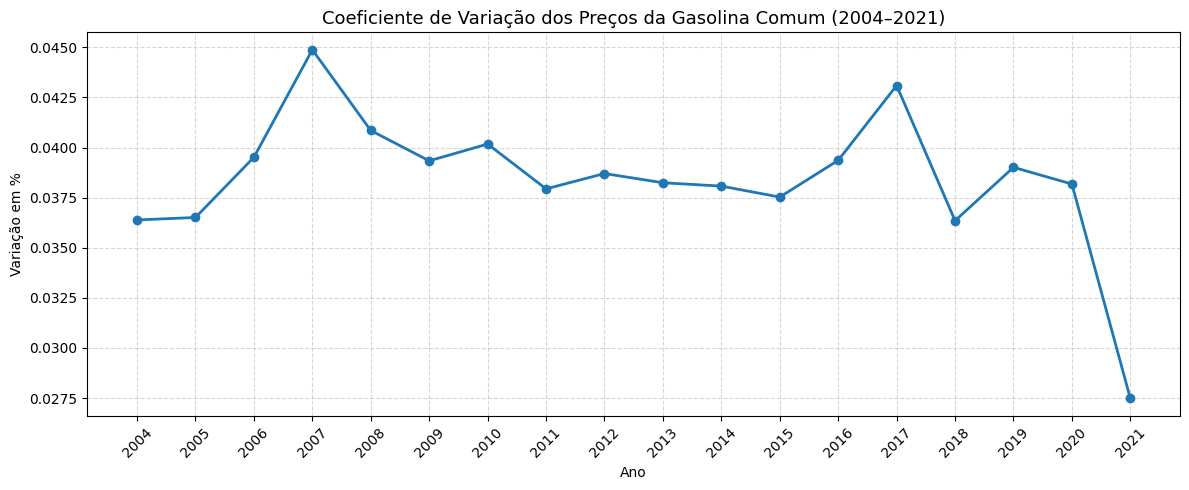

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))
cv_gasolina.plot(ax=ax, marker='o', linewidth=2)
ax.set_title('Coeficiente de Variação dos Preços da Gasolina Comum (2004–2021)', fontsize=13)
ax.set_xlabel('Ano')
ax.set_ylabel('Variação em %')
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_xticks(cv_gasolina.index)
ax.set_xticklabels(cv_gasolina.index, rotation=45)
plt.tight_layout()
plt.show()

O coeficiente de variação dos preços da Gasolina Comum oscilou entre 0,036 e 0,045 ao longo de toda a série, sem tendência clara de alta ou queda. O mercado manteve um grau de dispersão relativamente estável entre postos — dois picos notáveis em 2007 e 2017 coincidem com momentos de instabilidade de preços, sugerindo que choques externos aumentam temporariamente a heterogeneidade entre postos. O dado de 2021 foi excluído da interpretação por cobrir apenas até abril.

In [ ]:
df.to_csv('combustiveis_tratado.csv', index=False)

from google.colab import files
files.download('combustiveis_tratado.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving combustiveis_tratado (1).csv to combustiveis_tratado (1).csv


In [5]:
import pandas as pd
df = pd.read_csv('combustiveis_tratado (1).csv')
print(df.shape)
print(df.dtypes)

(120823, 20)
DATA INICIAL                      object
DATA FINAL                        object
REGIÃO                            object
ESTADO                            object
PRODUTO                           object
NÚMERO DE POSTOS PESQUISADOS       int64
UNIDADE DE MEDIDA                 object
PREÇO MÉDIO REVENDA              float64
DESVIO PADRÃO REVENDA            float64
PREÇO MÍNIMO REVENDA             float64
PREÇO MÁXIMO REVENDA             float64
MARGEM MÉDIA REVENDA             float64
COEF DE VARIAÇÃO REVENDA         float64
PREÇO MÉDIO DISTRIBUIÇÃO         float64
DESVIO PADRÃO DISTRIBUIÇÃO        object
PREÇO MÍNIMO DISTRIBUIÇÃO         object
PREÇO MÁXIMO DISTRIBUIÇÃO         object
COEF DE VARIAÇÃO DISTRIBUIÇÃO     object
ANO                                int64
MARGEM_CALCULADA                 float64
dtype: object


In [3]:
df['DATA INICIAL'] = pd.to_datetime(df['DATA INICIAL'])
df['DATA FINAL'] = pd.to_datetime(df['DATA FINAL'])

In [4]:
gasolina = df[df['PRODUTO'] == 'GASOLINA COMUM']
etanol = df[df['PRODUTO'] == 'ETANOL HIDRATADO']
df_margem = df[(df['MARGEM MÉDIA REVENDA'] > 0) & (df['MARGEM MÉDIA REVENDA'] < 2)]
df_margem2 = df[(df['MARGEM_CALCULADA'] > 0) & (df['MARGEM_CALCULADA'] < 2)]

In [6]:
df['DATA INICIAL'] = pd.to_datetime(df['DATA INICIAL'])
df['DATA FINAL'] = pd.to_datetime(df['DATA FINAL'])

gasolina = df[df['PRODUTO'] == 'GASOLINA COMUM']
etanol = df[df['PRODUTO'] == 'ETANOL HIDRATADO']
df_margem = df[(df['MARGEM MÉDIA REVENDA'] > 0) & (df['MARGEM MÉDIA REVENDA'] < 2)]
df_margem2 = df[(df['MARGEM_CALCULADA'] > 0) & (df['MARGEM_CALCULADA'] < 2)]

print('gasolina:', gasolina.shape)
print('etanol:', etanol.shape)
print('df_margem:', df_margem.shape)
print('df_margem2:', df_margem2.shape)

gasolina: (23570, 20)
etanol: (23440, 20)
df_margem: (89958, 20)
df_margem2: (89958, 20)


6. Em quais regiões e períodos o etanol foi competitivo (abaixo de 70% do preço da gasolina)?

In [7]:
pm_gasolina = gasolina.groupby(['ANO', 'REGIÃO'])['PREÇO MÉDIO REVENDA'].mean()
pm_etanol = etanol.groupby(['ANO', 'REGIÃO'])['PREÇO MÉDIO REVENDA'].mean()

print(pm_gasolina.head())
print(pm_etanol.head())

ANO   REGIÃO      
2004  CENTRO OESTE    2.288507
      NORDESTE        2.186523
      NORTE           2.351059
      SUDESTE         2.126941
      SUL             2.217078
Name: PREÇO MÉDIO REVENDA, dtype: float64
ANO   REGIÃO      
2004  CENTRO OESTE    1.502309
      NORDESTE        1.534441
      NORTE           1.736340
      SUDESTE         1.274912
      SUL             1.396853
Name: PREÇO MÉDIO REVENDA, dtype: float64


In [8]:
pm = pd.merge(
    pm_gasolina.reset_index(),
    pm_etanol.reset_index(),
    on=['ANO', 'REGIÃO'],
    suffixes=('_GASOLINA', '_ETANOL')
)

# Calcula a razão
pm['RAZAO'] = pm['PREÇO MÉDIO REVENDA_ETANOL'] / pm['PREÇO MÉDIO REVENDA_GASOLINA']

print(pm.head(10))

    ANO        REGIÃO  PREÇO MÉDIO REVENDA_GASOLINA  \
0  2004  CENTRO OESTE                      2.288507   
1  2004      NORDESTE                      2.186523   
2  2004         NORTE                      2.351059   
3  2004       SUDESTE                      2.126941   
4  2004           SUL                      2.217078   
5  2005  CENTRO OESTE                      2.497875   
6  2005      NORDESTE                      2.392278   
7  2005         NORTE                      2.541977   
8  2005       SUDESTE                      2.297705   
9  2005           SUL                      2.431240   

   PREÇO MÉDIO REVENDA_ETANOL     RAZAO  
0                    1.502309  0.656458  
1                    1.534441  0.701772  
2                    1.736340  0.738535  
3                    1.274912  0.599411  
4                    1.396853  0.630042  
5                    1.630055  0.652577  
6                    1.711411  0.715390  
7                    1.900959  0.747827  
8               

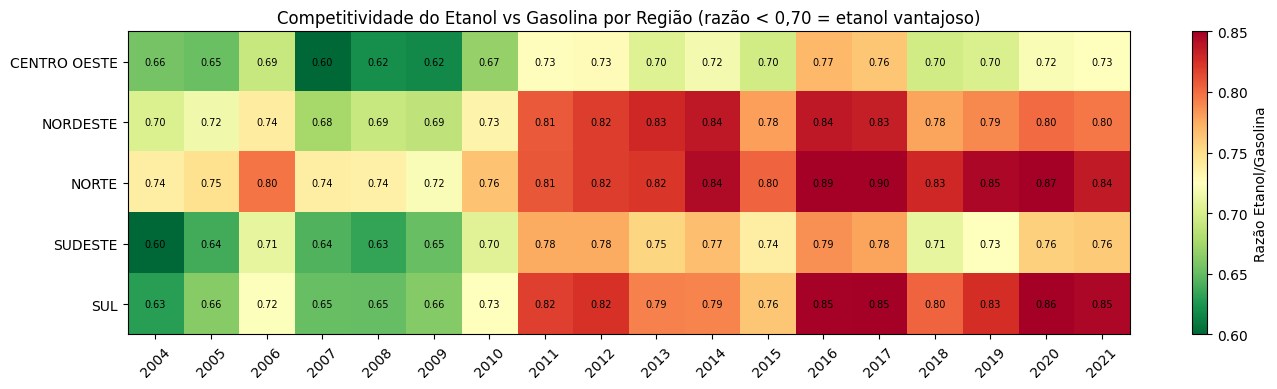

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# Pivota para formato de matriz: linhas = regiões, colunas = anos
heatmap_data = pm.pivot(index='REGIÃO', columns='ANO', values='RAZAO')

fig, ax = plt.subplots(figsize=(14, 4))

# Plota o heatmap colorindo pela razão
im = ax.imshow(heatmap_data.values, cmap='RdYlGn_r', vmin=0.60, vmax=0.85, aspect='auto')

# Eixos
ax.set_xticks(range(len(heatmap_data.columns)))
ax.set_xticklabels(heatmap_data.columns, rotation=45)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index)

# Linha de referência dos 70% como anotação em cada célula
for i in range(len(heatmap_data.index)):
    for j in range(len(heatmap_data.columns)):
        val = heatmap_data.values[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=7,
                color='black')

plt.colorbar(im, ax=ax, label='Razão Etanol/Gasolina')
ax.set_title('Competitividade do Etanol vs Gasolina por Região (razão < 0,70 = etanol vantajoso)', fontsize=12)
plt.tight_layout()
plt.show()